In [86]:
import mdtraj as md
import numpy as np

from tqdm import tqdm
from glob import glob

from pathlib import Path

from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Circle

In [87]:
def sci_notation_no_sigfigs(number, pos):
    a, b = f"{number:.0e}".split("e")
    b = int(b)
    if int(a) == 0 and b == 0:
        return "0"
    return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"


def sci_notation_one_sigfig(number, pos):
    a, b = f"{number:.1e}".split("e")
    b = int(b)
    if int(a) == 0 and b == 0:
        return "0"
    return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"

## Load MD and Crystal data

In [27]:
def load_simulation(glob_pattern, top_path, subsampling=1, atom_selection='(element != H) and is_protein', Ca_only=True):

    md_files = sorted(glob(glob_pattern))
    print(f"found {len(md_files)} trajectory files...")
    
    md_sim = None
    md_chis = []

    for f in tqdm(md_files):
    
        t = md.load(f, top=top_path)[::subsampling]
    
        idx = t.top.select(atom_selection)
        t   = t.atom_slice(idx)
        
        _, chis = md.compute_chi1(t)
        md_chis.extend(chis)

        if Ca_only:
            idx = t.top.select('name == CA')
            t   = t.atom_slice(idx)
    
        if md_sim == None:
            md_sim = t
        else:
            md_sim += t
    
    md_sim = md_sim.center_coordinates()
    md_chis = np.array(md_chis)
    
    return md_sim, md_chis

In [4]:
# DESRES
# sampling is 1 ns, so subsampled 1/1 is 1 ns

prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/mdsim/DESRES-Trajectory_sarscov2-10880334-no-water-no-ion-glueCA'
glob_pattern = prefix + '/sarscov2-10880334-no-water-no-ion-glueCA/*.dcd'
top_path = prefix + '/system_nowat.pdb'

desres_sim, desres_chi = load_simulation(glob_pattern, top_path, subsampling=1)

  0%|          | 0/100 [00:00<?, ?it/s]

found 100 trajectory files...


100%|██████████| 100/100 [01:45<00:00,  1.06s/it]


In [5]:
# RIKEN
# sampling is 200 ps, so subsampled 1/5 is 1 ns

prefix = '/gpfs/cfel/user/tjlane/mpro/mpro-simulations/RIKEN_mpro_simulation'
glob_pattern = prefix + '/Traj?/protein_snap_every200ps_*.xtc'
top_path = prefix + '/Traj1/protein_conf.gro'

riken_sim, riken_chi = load_simulation(glob_pattern, top_path, subsampling=5)

  0%|          | 0/6 [00:00<?, ?it/s]

found 6 trajectory files...


100%|██████████| 6/6 [00:53<00:00,  8.90s/it]


In [6]:
# Amaro Lab
# sampling is 100 ps, so subsampled 1/10 is 1 ns
# the simulation is split into two: different DCD and topologies for each chain...

prefix = '/gpfs/cfel/user/tjlane/mpro/mpro-simulations/TRAJECTORIES_INPUTS_DATA_mpro_wt_variants_amarolab/wt'

glob_pattern_chainA = prefix + '/wt_mpro_chainA_*.dcd'
top_path_chainA = prefix + '/wt_mpro_chainA_rep123.pr5.aligned_CA.not_waters_or_ions.psf'

glob_pattern_chainB = prefix + '/wt_mpro_chainB_*.dcd'
top_path_chainB = prefix + '/wt_mpro_chainB_rep123.pr5.aligned_CA.not_waters_or_ions.psf'

amaro_sim_A, amaro_chi_A = load_simulation(glob_pattern_chainA, top_path_chainA, subsampling=10)
amaro_sim_B, amaro_chi_B = load_simulation(glob_pattern_chainB, top_path_chainB, subsampling=10)

  0%|          | 0/3 [00:00<?, ?it/s]

found 3 trajectory files...


  0%|          | 0/3 [00:00<?, ?it/s]

found 3 trajectory files...


100%|██████████| 3/3 [00:25<00:00,  8.44s/it]


In [7]:
print(desres_sim.xyz.shape, desres_chi.shape)
print(riken_sim.xyz.shape, riken_chi.shape)
print(amaro_sim_A.xyz.shape,  amaro_chi_A.shape)
print(amaro_sim_B.xyz.shape,  amaro_chi_B.shape)

(100000, 612, 3) (100000, 526)
(20000, 612, 3) (20000, 526)
(33000, 306, 3) (33000, 263)
(33000, 301, 3) (33000, 259)


In [8]:
active_site_residues = np.array([41, 49, 143, 144, 145, 163, 164, 165, 166, 167, 187, 188, 189, 190, 191, 192]) - 3

residues = list(desres_sim.top.residues)
asr_names = [ residues[asr].name + str(residues[asr].resSeq) for asr in active_site_residues ]

print(asr_names)

['PRO39', 'GLU47', 'LEU141', 'ASN142', 'GLY143', 'TYR161', 'MET162', 'HIS163', 'HIS164', 'MET165', 'PHE185', 'VAL186', 'ASP187', 'ARG188', 'GLN189', 'THR190']


## Compute Ca covariance tensor

In [9]:
def isotropic_cov(xyz):
    
    # we want X.T * X summed over last dim
    # put it in B-factor units
    S = 8.0 * np.square(np.pi) * ( np.cov(xyz[:,:,0].T) + np.cov(xyz[:,:,1].T) + np.cov(xyz[:,:,2].T) )
    
    return S

In [10]:
S_desres = isotropic_cov(desres_sim.xyz)
S_riken  = isotropic_cov(riken_sim.xyz)

# the Amaro simulation is missing a few residues (not sure why), so pad the XYZ trajectory with zeros so that it lines up with others
S_amaro = isotropic_cov(np.concatenate([amaro_sim_A.xyz, np.zeros([33000, 1, 3]), amaro_sim_B.xyz, np.zeros([33000, 6, 3])], axis=1))

for S in [S_desres, S_riken, S_amaro]:
    print(S.shape)

(612, 612)
(612, 612)
(614, 614)


132.8709436211427


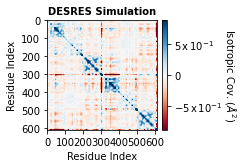

148.29389026944932


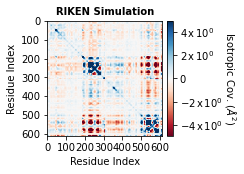

208.27817160484898


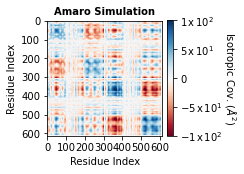

In [11]:
ticks = np.arange(0, desres_sim.xyz.shape[1], 100)
cmap = 'RdBu'

# title, matrix to plot, filename to save
datasets = [
    ('DESRES Simulation', S_desres[:,:], "desres_sim"),
    ('RIKEN Simulation', S_riken[:,:], "riken_sim"),
    ('Amaro Simulation', S_amaro[:,:], "amaro_sim"),
]


# how much to zoom colorbar
scales = [
    0.9,
    5.,
    100.0,
]

for i_d, dataset in enumerate(datasets):

    figsize = (3.5,3.5)

    fig = plt.figure(figsize=figsize)
    ax1 = plt.subplot(111)

    ax1.set_title(dataset[0], 
                  fontweight='bold', fontsize=10)
    

    print(dataset[1].max())
    im = ax1.imshow(
        dataset[1],
        cmap=cmap, 
        vmin=-scales[i_d],
        vmax=scales[i_d],
        interpolation=None,
    )

    ax1.set_xticks(ticks)
    ax1.set_xticklabels([str(int(t)) for t in ticks])
    ax1.set_yticks(ticks)
    ax1.set_yticklabels([str(int(t)) for t in ticks])
    ax1.set_xlabel('Residue Index')
    ax1.set_ylabel('Residue Index')
    
    # ax1.set_xticks([])
    # ax1.set_yticks([])

    cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, format=FuncFormatter(sci_notation_no_sigfigs))
    
    cbar.set_label('Isotropic Cov. ($\AA^2$)', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.savefig(f'./figures/covariance_matrices/{dataset[2]}.pdf')
    plt.show()

    np.save(f"./covariance_matrices/{dataset[2]}.npy", dataset[1])

In [12]:
mu_desres  = np.abs(S_desres[active_site_residues,:]).mean(0)
std_desres = np.abs(S_desres[active_site_residues,:]).std(0)

mu_riken  = np.abs(S_riken[active_site_residues,:]).mean(0)
std_riken = np.abs(S_riken[active_site_residues,:]).std(0)

mu_amaro  = np.abs(S_amaro[active_site_residues,:]).mean(0)
std_amaro = np.abs(S_amaro[active_site_residues,:]).std(0)

## View correlation projected on active site

In [13]:
res_idx = np.arange(S_desres.shape[0]) + 3

In [14]:
# plt.figure(figsize=(5,3))

# ax1 = plt.subplot(111)

# ax1.plot(res_idx, mu_xtal, color='b')

# ax1.fill_between(res_idx, mu_xtal - err_mu_xtal * 3, mu_xtal + err_mu_xtal * 3, 
#                 alpha=0.3, color='grey')

# ax1.set_xlabel(r'Residue Index')
# ax1.set_ylabel(r'Mean $C_\alpha$ Cov. to Active Site ($\AA^2$)')
# #ax1.set_yticks([])
# ax1.yaxis.set_major_formatter(FuncFormatter(sci_notation_one_sigfig))

# BAR_SIZE = 0.0012
# BAR_FLOOR = -0.001

# # crystal contacts
# cont = ax1.vlines(24, BAR_FLOOR, BAR_FLOOR + BAR_SIZE, color='r')
# ax1.vlines(60, BAR_FLOOR, BAR_FLOOR + BAR_SIZE, color='r')
# ax1.vlines(222, BAR_FLOOR, BAR_FLOOR + BAR_SIZE, color='r')

# # active site residues
# for r in active_site_residues:
#     act = ax1.vlines(r+3, BAR_FLOOR, BAR_FLOOR + BAR_SIZE)

# # interesting
# x_shift = -0
# y_shift = 0.005
# ax1.text(210 + x_shift, mu_xtal[213] + y_shift + 0.001,  'N214', weight='bold')
# ax1.text(252 + x_shift, mu_xtal[255] + y_shift - 0.0005, 'Q256', weight='bold')
# ax1.text(282 + x_shift, mu_xtal[283] + y_shift,  'S284', weight='bold')

# ax1.vlines(214, 0.01, 0.012)
# ax1.vlines(256, 0.0085, 0.0105)
# ax1.vlines(284, 0.0075, 0.0085)

# ax1.spines['top'].set_visible(False)
# ax1.spines['right'].set_visible(False)
    
# plt.legend([act, cont], ['active site', 'crystal contact'], loc=2)
    
# plt.tight_layout()
# plt.savefig('figures/cov_to_active.pdf')
# plt.show()

In [15]:
hotspot_residues = np.array([214, 256, 284, 214+306, 256+306, 284+306]) - 3

for sim in [desres_sim, riken_sim]:
    residues = list(sim.top.residues)
    asr_names = [ residues[asr].name + str(residues[asr].resSeq) for asr in hotspot_residues ] 
    print(asr_names)

hotspot_residues = np.array([214, 256, 284]) - 3

for sim in [amaro_sim_A, amaro_sim_B]:
    residues = list(sim.top.residues)
    asr_names = [ residues[asr].name + str(residues[asr].resSeq) for asr in hotspot_residues ] 
    print(asr_names)

['VAL212', 'SER254', 'LEU282', 'VAL212', 'SER254', 'LEU282']
['VAL212', 'SER254', 'LEU282', 'VAL212', 'SER254', 'LEU282']
['VAL212', 'SER254', 'LEU282']
['VAL212', 'SER254', 'LEU282']


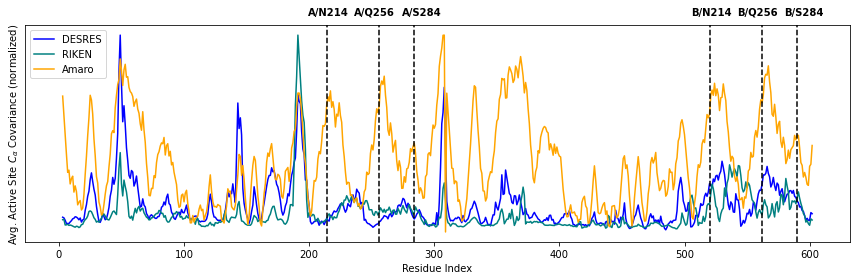

In [16]:
SEQUENCE_CUTOFF = 600
RESIDUES_OF_INTEREST = [214, 256, 284, 214+306, 256+306, 284+306]

plt.figure(figsize=(12,4))

ax1 = plt.subplot(111)

p1 = ax1.plot(res_idx[:SEQUENCE_CUTOFF], mu_desres[:SEQUENCE_CUTOFF] / mu_desres[:SEQUENCE_CUTOFF].max(), color='b')
p2 = ax1.plot(res_idx[:SEQUENCE_CUTOFF], mu_riken[:SEQUENCE_CUTOFF] / mu_riken[:SEQUENCE_CUTOFF].max(), color='teal')
p3 = ax1.plot(res_idx[:SEQUENCE_CUTOFF], mu_amaro[:SEQUENCE_CUTOFF] / mu_amaro[:SEQUENCE_CUTOFF].max(), color='orange')

ax1.set_xlabel('Residue Index')
ax1.set_ylabel(r'Avg. Active Site $C_\alpha$ Covariance (normalized)')
ax1.set_yticks([])

x_shift = 15
ax1.text(214-x_shift, 1.1,  'A/N214', weight='bold')
ax1.text(256-x_shift-5, 1.105,  'A/Q256', weight='bold')
ax1.text(284-x_shift+5, 1.1,  'A/S284', weight='bold')

ax1.text(214-x_shift + 306, 1.1,  'B/N214', weight='bold')
ax1.text(256-x_shift + 306 - 5, 1.105,  'B/Q256', weight='bold')
ax1.text(284-x_shift + 306 + 5, 1.1,  'B/S284', weight='bold')

for residue in RESIDUES_OF_INTEREST:
    ax1.axvline(x=residue, color="k", linestyle="--")

plt.legend(['DESRES', 'RIKEN', 'Amaro'], loc=2)
 
plt.savefig('figures/md_simulation_comparison_correlation_to_active.pdf')
plt.tight_layout()
plt.show()

## Run PCA on the DESRES data, and project the other simulations into the space of the first 2 PCs

In [28]:
# first, we need the crystal data

CRYSTAL_ATOM_SELECTION = '(element != H) and is_protein and (resi < 303) and (resi > 1)'

def load_pdbs(glob_pattern, Ca_only=True):
    
    crystals = None
    crystal_chis = []

    first = True
    files_to_load = sorted(glob(glob_pattern))
    
    for pdb in tqdm(files_to_load):

        try:
            
            trj = md.load_pdb(pdb)
            idx = trj.top.select(CRYSTAL_ATOM_SELECTION)
            trj = trj.atom_slice(idx)

            chi_atoms, chi = md.compute_chi1(trj)
            crystal_chis.extend(chi)

            if first:
                chi_idx = [ trj.topology.atom(int(a)).residue.index for a in chi_atoms[:,0] ]
                first = False

            if Ca_only:
                idx = trj.top.select('name == CA')
                trj = trj.atom_slice(idx)

            if crystals:
                crystals = crystals.join(trj, check_topology=False)
            else:
                crystals = trj

        except Exception as exptn:
            print(trj.xyz.shape)
            print(crystals.xyz.shape)
            print("something went wrong", pdb, exptn)

    crystals = crystals.center_coordinates()
    crystal_chis = np.array(crystal_chis)
    
    return crystals, crystal_chis


def featurize_all_dihedrals(traj):
    
    features = []
    for fxn in [md.compute_phi,
                md.compute_psi]:
        _, angles = fxn(traj)
        
        features.append( np.sin(angles) )
        features.append( np.cos(angles) )
    
    return np.hstack(features)

In [29]:
crystals, _ = load_pdbs('../../allostery/selected_dataset_archive_2024-08-07/pdb/*.pdb', Ca_only=False)

prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/diamond_05-May-2020/'
diamond, _ = load_pdbs(prefix + '*.pdb', Ca_only=False)

 58%|█████▊    | 61/105 [00:12<00:08,  5.47it/s]

(1, 2319, 3)
(59, 2330, 3)
something went wrong /asap3/petra3/gpfs/p11/2020/data/11009999/shared/diamond_05-May-2020/Mpro-x1187_0.pdb Number of atoms in self (2330) is not equal to number of atoms in other


100%|██████████| 105/105 [00:21<00:00,  4.91it/s]


In [30]:
# then we need to cut down the MD simulations so they match the residue indices of the crystals

# DESRES
prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/mdsim/DESRES-Trajectory_sarscov2-10880334-no-water-no-ion-glueCA'
glob_pattern = prefix + '/sarscov2-10880334-no-water-no-ion-glueCA/*.dcd'
top_path = prefix + '/system_nowat.pdb'

desres_sim_subset, _ = load_simulation(glob_pattern, top_path, subsampling=1, atom_selection=CRYSTAL_ATOM_SELECTION, Ca_only=False)

# RIKEN
# sampling is 200 ps, so subsampled 1/5 is 1 ns

prefix = '/gpfs/cfel/user/tjlane/mpro/mpro-simulations/RIKEN_mpro_simulation'
glob_pattern = prefix + '/Traj?/protein_snap_every200ps_*.xtc'
top_path = prefix + '/Traj1/protein_conf.gro'

riken_sim_subset, _ = load_simulation(glob_pattern, top_path, subsampling=5, atom_selection=CRYSTAL_ATOM_SELECTION, Ca_only=False)

# Amaro Lab
# sampling is 100 ps, so subsampled 1/10 is 1 ns
# the simulation is split into two: different DCD and topologies for each chain...

prefix = '/gpfs/cfel/user/tjlane/mpro/mpro-simulations/TRAJECTORIES_INPUTS_DATA_mpro_wt_variants_amarolab/wt'

glob_pattern_chainA = prefix + '/wt_mpro_chainA_*.dcd'
top_path_chainA = prefix + '/wt_mpro_chainA_rep123.pr5.aligned_CA.not_waters_or_ions.psf'

amaro_sim_subset, _ = load_simulation(glob_pattern_chainA, top_path_chainA, subsampling=10, atom_selection=CRYSTAL_ATOM_SELECTION, Ca_only=False)

  0%|          | 0/100 [00:00<?, ?it/s]

found 100 trajectory files...


  0%|          | 0/6 [00:00<?, ?it/s]

found 6 trajectory files...


  0%|          | 0/3 [00:00<?, ?it/s]

found 3 trajectory files...


100%|██████████| 3/3 [00:22<00:00,  7.66s/it]


In [31]:
crystal_features = featurize_all_dihedrals(crystals)
diamond_features = featurize_all_dihedrals(diamond)
desres_features = featurize_all_dihedrals(desres_sim_subset)
riken_features = featurize_all_dihedrals(riken_sim_subset)
amaro_features = featurize_all_dihedrals(amaro_sim_subset)

all_features = [crystal_features, diamond_features, desres_features, riken_features, amaro_features]

for features in all_features:
    print(features.shape)

(1146, 1200)
(104, 1200)
(100000, 1200)
(20000, 1200)
(33000, 1200)


In [88]:
titles = ["lig. free M$^\mathrm{pro}$ crystals", "Diamond", "DESRES MD Sim.", "RIKEN MD Sim.", "Amaro MD Sim."]

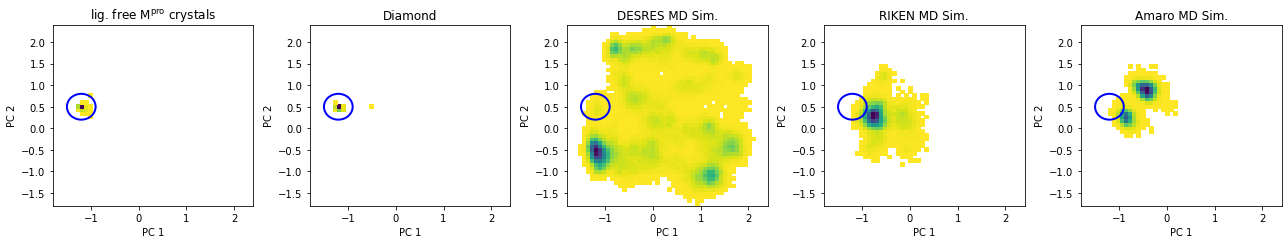

In [102]:
pca = PCA(n_components=2, svd_solver='full', whiten=True)
Y_tr = pca.fit_transform(desres_features)

plt.figure(figsize=(18,3.5))

for i_f, features in enumerate(all_features):

    Y = pca.transform(features)

    ax = plt.subplot(1, len(all_features), i_f+1)
    ax.hist2d(Y[:,0], Y[:,1], bins=50, cmap='viridis_r', density=True, cmin=.001, range=[(-1.8, 2.4),(-1.8, 2.4)])

    circle = Circle((-1.2, 0.5), 0.3, color='blue', fill=False, linewidth=2)
    ax.add_patch(circle)

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")

    ax.set_title(titles[i_f])

plt.tight_layout()
plt.savefig("./figures/PCA_comparison_crystals_MD-DESRES_PCs.pdf")
plt.show()

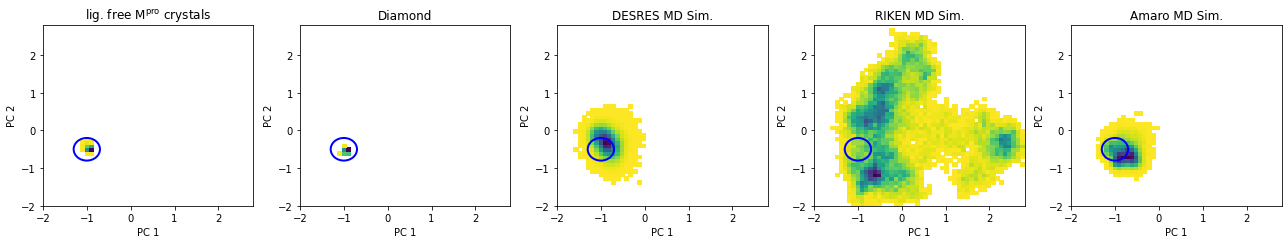

In [105]:
# same plot, RIKEN PCs

pca = PCA(n_components=2, svd_solver='full', whiten=True)
Y_tr = pca.fit_transform(riken_features)

plt.figure(figsize=(18,3.5))

for i_f, features in enumerate(all_features):

    Y = pca.transform(features)

    ax = plt.subplot(1, len(all_features), i_f+1)
    ax.hist2d(Y[:,0], Y[:,1], bins=50, cmap='viridis_r', density=True, cmin=.001, range=[(-2, 2.8),(-2, 2.8)])

    circle = Circle((-1., -0.5), 0.3, color='blue', fill=False, linewidth=2)
    ax.add_patch(circle)

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")

    ax.set_title(titles[i_f])

plt.tight_layout()
plt.savefig("./figures/PCA_comparison_crystals_MD-RIKEN_PCs.pdf")
plt.show()

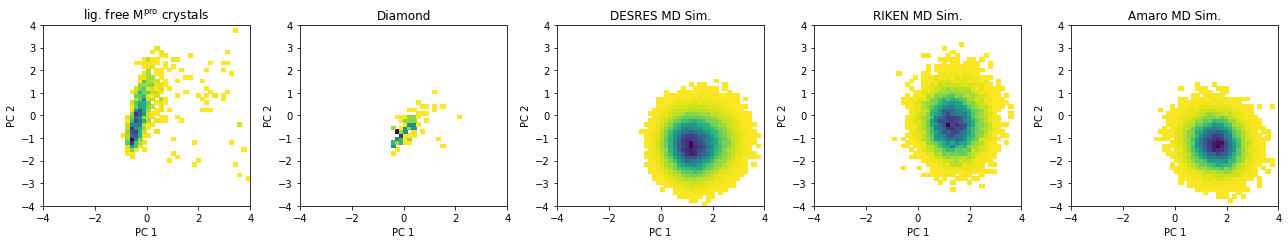

In [99]:
# same plot, use crystal-based PCs

pca = PCA(n_components=2, svd_solver='full', whiten=True)
Y_tr = pca.fit_transform(crystal_features)

titles = ["lig. free M$^\mathrm{pro}$ crystals", "Diamond", "DESRES MD Sim.", "RIKEN MD Sim.", "Amaro MD Sim."]

plt.figure(figsize=(18,3.5))

for i_f, features in enumerate(all_features):

    Y = pca.transform(features)

    ax = plt.subplot(1, len(all_features), i_f+1)
    ax.hist2d(Y[:,0], Y[:,1], bins=50, cmap='viridis_r', density=True, cmin=.001, range=[(-4,4), (-4,4)])

    #circle = Circle((-1.2, 0.5), 0.3, color='blue', fill=False, linewidth=2)
    #ax.add_patch(circle)

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")

    ax.set_title(titles[i_f])

plt.tight_layout()
plt.savefig("./figures/PCA_comparison_crystals_MD-crystal_PCs.pdf")
plt.show()